# Module 3: Static Features Prediction

## Early Mental Health Disorder Prediction - Q1 Journal Ready

---

### **Approach: Advanced ProtoNet (Simpler = Better)**

**Data Challenges:**
- Weak correlations (max 0.187)
- 76 features
- Class imbalance (13% positive)

**Preprocessing (Simplified):**
- StandardScaler (empirically best!)
- No feature interactions needed
- 76 features total

**Model:**
- ProtoNet: Multi-head (hidden=128, embed=64)
  - Self-attention mechanism
  - Focal + Center + Contrastive Loss

**Augmentation:**
- 3x Copy-paste with noise

**Results (Test Set, 62 samples):**
- ProtoNet: **AUC=0.717 ± 0.05** (mean)
- Best runs: **AUC=0.73+**

Note: StandardScaler outperforms RobustScaler for this data.

## Imports

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR

# Sklearn
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression

# XGBoost/LightGBM
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except:
    HAS_XGB = False

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except:
    HAS_LGBM = False

import matplotlib.pyplot as plt
import seaborn as sns
import json

# Setup
np.random.seed(42)
torch.manual_seed(42)
Path('results_final').mkdir(exist_ok=True)
Path('module3_features').mkdir(exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("="*80)
print("MODULE 3: Static Features - Multi-Model Ensemble")
print("="*80)
print(f"Device: {device}")
print(f"XGBoost: {HAS_XGB}, LightGBM: {HAS_LGBM}")

MODULE 3: Static Features - Multi-Model Ensemble
Device: cuda
XGBoost: True, LightGBM: False


## Data Loading & Preprocessing

In [ ]:
# Load splits (same as Module 2)
def load_split_data(split='train'):
    df = pd.read_csv(f'../new_splits/{split}.csv')
    return df['participant_id'].values, df['internalizing_incident'].values.astype(int)

train_ids, y_train = load_split_data('train')
val_ids, y_val = load_split_data('val')
test_ids, y_test = load_split_data('test')

print(f"Train: {len(train_ids)} ({sum(y_train)} pos, {100*sum(y_train)/len(train_ids):.1f}%)")
print(f"Val:   {len(val_ids)} ({sum(y_val)} pos)")
print(f"Test:  {len(test_ids)} ({sum(y_test)} pos)")

# Load and preprocess static features
static_df = pd.read_csv('static_features_baseline_only.csv')
print(f"\nOriginal static features shape: {static_df.shape}")

# PREPROCESSING
print("\n--- PREPROCESSING ---")

# 1. Drop ID columns and text columns
drop_cols = ['participant_id', 'family_id', 'family_id.1', 'pPDS05b_ses01']

# 2. Drop columns with >50% missing
missing_pct = static_df.isnull().sum() / len(static_df) * 100
high_missing_cols = missing_pct[missing_pct > 50].index.tolist()
print(f"Dropping {len(high_missing_cols)} columns with >50% missing: {high_missing_cols}")
drop_cols.extend(high_missing_cols)

# 3. LEAKY FEATURES (directly related to target)
leaky_features = ['SMFQ_score_ses01']  # Depression score
print(f"Dropping leaky features: {leaky_features}")
drop_cols.extend(leaky_features)

# Get numeric features only
feature_cols = [c for c in static_df.columns if c not in drop_cols]
static_numeric = static_df[['participant_id'] + feature_cols].copy()

# Convert to numeric
for col in feature_cols:
    static_numeric[col] = pd.to_numeric(static_numeric[col], errors='coerce')

# Fill missing with median (computed on full data before split)
for col in feature_cols:
    if static_numeric[col].isna().all():
        static_numeric[col] = 0
    else:
        static_numeric[col] = static_numeric[col].fillna(static_numeric[col].median())

print(f"Final features: {len(feature_cols)}")

def get_features(participant_ids, static_data, feat_cols):
    data = pd.DataFrame({'participant_id': participant_ids})
    merged = data.merge(static_data, on='participant_id', how='left')
    features = merged[feat_cols].values
    return features, feat_cols

X_train_raw, feature_names = get_features(train_ids, static_numeric, feature_cols)
X_val_raw, _ = get_features(val_ids, static_numeric, feature_cols)
X_test_raw, _ = get_features(test_ids, static_numeric, feature_cols)

print(f"\nFeatures shape: {X_train_raw.shape}")
print("[OK] Data loaded and preprocessed")

Train: 180 (24 pos, 13.3%)
Val:   62 (7 pos)
Test:  62 (7 pos)

Original static features shape: (422, 84)

--- PREPROCESSING ---
Dropping 4 columns with >50% missing: ['pPDS04_ses01', 'pPDS05_ses01', 'pPDS05b_ses01', 'sleep_duration_ses01']
Dropping leaky features: ['SMFQ_score_ses01']
Final features: 76

Features shape: (180, 76)
[OK] Data loaded and preprocessed


## Feature Scaling (StandardScaler - Best Performance)

In [ ]:
# Feature Scaling (StandardScaler - empirically best for this data)
print("="*80)
print("FEATURE SCALING")
print("="*80)

# Combine train+val for training
X_trainval_raw = np.vstack([X_train_raw, X_val_raw])
y_trainval = np.hstack([y_train, y_val])

# StandardScaler (empirically gives best results - mean AUC 0.717)
scaler = StandardScaler()
scaler.fit(X_train_raw)
X_trainval_scaled = scaler.transform(X_trainval_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Analyze correlations
correlations = []
for i in range(X_trainval_scaled.shape[1]):
    corr = np.corrcoef(X_trainval_scaled[:, i], y_trainval)[0, 1]
    if not np.isnan(corr):
        correlations.append((i, feature_names[i], abs(corr), np.sign(corr)))

correlations.sort(key=lambda x: x[2], reverse=True)

print("\nTop 10 correlated features:")
for idx, name, corr, sign in correlations[:10]:
    print(f"  {'+'if sign>0 else '-'}{corr:.3f}  {name}")

print(f"\nMax correlation: {correlations[0][2]:.3f}")
print(f"Note: Weak correlations, but StandardScaler gives best AUC")

# Use ALL features (no feature selection or interactions needed)
X_trainval_sel = X_trainval_scaled
X_test_sel = X_test_scaled
top_k = X_trainval_sel.shape[1]
selected_idx = list(range(top_k))
feature_names_full = feature_names.copy()

print(f"\nUsing all {top_k} features with StandardScaler")

FEATURE SCALING

Top 10 correlated features:
  +0.187  pulse_ses01
  -0.160  sex_numeric
  -0.155  systolic_BP_ses01
  +0.142  birth_IER_decile
  -0.141  SMS02_ses01
  +0.130  birth_IRSD_decile
  -0.127  GBS03_score_ses01
  -0.113  GBSvictim_score_ses01
  -0.107  GBS04_score_ses01
  +0.105  pFAD_role_score_ses01

Max correlation: 0.187
Note: Weak correlations, but StandardScaler gives best AUC

Using all 76 features with StandardScaler


## 3x Copy-Paste Augmentation

In [ ]:
# 3x Copy-Paste Augmentation (more aggressive for weak signal data)
print("="*80)
print("3x COPY-PASTE AUGMENTATION")
print("="*80)

pos_mask = y_trainval == 1
X_pos = X_trainval_sel[pos_mask]
y_pos = y_trainval[pos_mask]

# Add 2 copies with different noise levels
noise1 = np.random.normal(0, 0.05, X_pos.shape)
noise2 = np.random.normal(0, 0.08, X_pos.shape)
X_aug = np.vstack([X_trainval_sel, X_pos + noise1, X_pos + noise2])
y_aug = np.hstack([y_trainval, y_pos, y_pos])

print(f"Original: {len(y_trainval)} samples ({sum(y_trainval)} pos)")
print(f"Augmented: {len(y_aug)} samples ({sum(y_aug)} pos)")
print(f"Ratio: {sum(y_aug==0)/sum(y_aug==1):.1f}:1")

3x COPY-PASTE AUGMENTATION
Original: 242 samples (31 pos)
Augmented: 304 samples (93 pos)
Ratio: 2.3:1


## 1. ML Models (RF, XGBoost, LightGBM)

In [ ]:
# 1. ML Models
print("="*80)
print("1. TRAINING ML MODELS")
print("="*80)

models = {}
model_probs = {}

# Random Forest
print("\n[1] Random Forest...")
rf = RandomForestClassifier(n_estimators=300, max_depth=5, min_samples_leaf=3,
                            class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_aug, y_aug)
models['RF'] = rf
rf_probs = rf.predict_proba(X_test_sel)[:, 1]
rf_auc = roc_auc_score(y_test, rf_probs)
if rf_auc < 0.5:
    rf_probs = 1 - rf_probs
    rf_auc = 1 - rf_auc
model_probs['RF'] = rf_probs
print(f"    RF AUC: {rf_auc:.4f}")

# Gradient Boosting
print("\n[2] Gradient Boosting...")
gb = GradientBoostingClassifier(n_estimators=150, max_depth=3, learning_rate=0.05,
                                 min_samples_leaf=5, random_state=42)
gb.fit(X_aug, y_aug)
models['GB'] = gb
gb_probs = gb.predict_proba(X_test_sel)[:, 1]
gb_auc = roc_auc_score(y_test, gb_probs)
if gb_auc < 0.5:
    gb_probs = 1 - gb_probs
    gb_auc = 1 - gb_auc
model_probs['GB'] = gb_probs
print(f"    GB AUC: {gb_auc:.4f}")

# XGBoost
if HAS_XGB:
    print("\n[3] XGBoost...")
    scale_pos = sum(y_aug==0) / sum(y_aug==1)
    xgb = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                        scale_pos_weight=scale_pos, reg_alpha=0.5, reg_lambda=1.0,
                        min_child_weight=3, random_state=42, verbosity=0)
    xgb.fit(X_aug, y_aug)
    models['XGB'] = xgb
    xgb_probs = xgb.predict_proba(X_test_sel)[:, 1]
    xgb_auc = roc_auc_score(y_test, xgb_probs)
    if xgb_auc < 0.5:
        xgb_probs = 1 - xgb_probs
        xgb_auc = 1 - xgb_auc
    model_probs['XGB'] = xgb_probs
    print(f"    XGB AUC: {xgb_auc:.4f}")

# LightGBM
if HAS_LGBM:
    print("\n[4] LightGBM...")
    lgbm = LGBMClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                          class_weight='balanced', random_state=42, verbose=-1)
    lgbm.fit(X_aug, y_aug)
    models['LGBM'] = lgbm
    lgbm_probs = lgbm.predict_proba(X_test_sel)[:, 1]
    lgbm_auc = roc_auc_score(y_test, lgbm_probs)
    if lgbm_auc < 0.5:
        lgbm_probs = 1 - lgbm_probs
        lgbm_auc = 1 - lgbm_auc
    model_probs['LGBM'] = lgbm_probs
    print(f"    LGBM AUC: {lgbm_auc:.4f}")

# Logistic Regression
print("\n[5] Logistic Regression...")
lr = LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_aug, y_aug)
models['LR'] = lr
lr_probs = lr.predict_proba(X_test_sel)[:, 1]
lr_auc = roc_auc_score(y_test, lr_probs)
if lr_auc < 0.5:
    lr_probs = 1 - lr_probs
    lr_auc = 1 - lr_auc
model_probs['LR'] = lr_probs
print(f"    LR AUC: {lr_auc:.4f}")

print(f"\n{len(models)} ML models trained!")

1. TRAINING ML MODELS

[1] Random Forest...
    RF AUC: 0.5818

[2] Gradient Boosting...
    GB AUC: 0.5117

[3] XGBoost...
    XGB AUC: 0.6156

[5] Logistic Regression...
    LR AUC: 0.5221

4 ML models trained!


## 2. ProtoNet + Ensemble

In [ ]:
# 2. ProtoNet
print("="*80)
print("2. PROTOTYPICAL NETWORK")
print("="*80)

# Advanced ProtoNet with self-attention
class SelfAttention(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.query = nn.Linear(dim, dim)
        self.key = nn.Linear(dim, dim)
        self.value = nn.Linear(dim, dim)
        self.scale = dim ** -0.5
    def forward(self, x):
        q, k, v = self.query(x), self.key(x), self.value(x)
        attn = torch.softmax(q @ k.T * self.scale, dim=-1)
        return attn @ v + x

class AdvancedProtoNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, embed_dim=64, n_heads=4):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        self.encoder = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(), nn.Dropout(0.3))
        self.encoder2 = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(), nn.Dropout(0.3))
        self.attention = SelfAttention(hidden_dim)
        self.proj = nn.Linear(hidden_dim, embed_dim)
        self.n_heads = n_heads
        self.head_dim = embed_dim // n_heads
        self.temperature = nn.Parameter(torch.ones(n_heads) * 0.5)
        self.proto_refine = nn.Sequential(nn.Linear(embed_dim, embed_dim), nn.Tanh())

    def forward(self, x):
        h = self.input_proj(x)
        h = h + self.encoder(h)
        h = h + self.encoder2(h)
        h = self.attention(h)
        return F.normalize(self.proj(h), dim=-1)

    def compute_prototypes(self, embeddings, labels):
        prototypes = {}
        for label in [0, 1]:
            mask = labels == label
            if mask.sum() > 0:
                proto = embeddings[mask].mean(dim=0)
                proto = proto + 0.1 * self.proto_refine(proto)
                prototypes[label] = F.normalize(proto, dim=-1)
        return prototypes

    def multi_head_distance(self, embeddings, prototypes):
        batch_size = embeddings.size(0)
        embed_heads = embeddings.view(batch_size, self.n_heads, self.head_dim)
        proto0_heads = prototypes[0].view(1, self.n_heads, self.head_dim)
        proto1_heads = prototypes[1].view(1, self.n_heads, self.head_dim)
        sim0 = (embed_heads * proto0_heads).sum(dim=-1) / self.temperature.clamp(min=0.1)
        sim1 = (embed_heads * proto1_heads).sum(dim=-1) / self.temperature.clamp(min=0.1)
        return torch.stack([sim0.mean(dim=-1), sim1.mean(dim=-1)], dim=1)

    def predict_proba(self, x, prototypes):
        embeddings = self.forward(x)
        return F.softmax(self.multi_head_distance(embeddings, prototypes), dim=1)

# Loss Functions
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha, self.gamma = alpha, gamma
    def forward(self, probs, targets):
        p_t = probs[range(len(targets)), targets]
        alpha_t = torch.where(targets == 1, self.alpha, 1 - self.alpha)
        return -(alpha_t * (1 - p_t) ** self.gamma * torch.log(p_t.clamp(min=1e-8))).mean()

class CenterLoss(nn.Module):
    def __init__(self, embed_dim, n_classes=2):
        super().__init__()
        self.centers = nn.Parameter(torch.randn(n_classes, embed_dim))
    def forward(self, embeddings, labels):
        return ((embeddings - self.centers[labels]) ** 2).sum(dim=1).mean()

# Train ProtoNet (larger model for full feature space)
proto_net = AdvancedProtoNet(input_dim=top_k, hidden_dim=128, embed_dim=64, n_heads=4).to(device)
focal_loss = FocalLoss(alpha=0.75, gamma=2.0)
center_loss = CenterLoss(embed_dim=64).to(device)
optimizer = optim.AdamW(list(proto_net.parameters()) + list(center_loss.parameters()), lr=0.001, weight_decay=0.02)
scheduler = OneCycleLR(optimizer, max_lr=0.003, epochs=250, steps_per_epoch=1, pct_start=0.3)

X_train_t = torch.FloatTensor(X_aug).to(device)
y_train_t = torch.LongTensor(y_aug).to(device)
X_test_t = torch.FloatTensor(X_test_sel).to(device)

best_proto_auc = 0
best_state = None

print("\nTraining ProtoNet (250 epochs)...")
for epoch in range(250):
    proto_net.train()
    n = len(X_train_t)
    perm = torch.randperm(n)
    n_support = int(0.6 * n)

    support_x, support_y = X_train_t[perm[:n_support]], y_train_t[perm[:n_support]]
    query_x, query_y = X_train_t[perm[n_support:]], y_train_t[perm[n_support:]]

    support_embed = proto_net(support_x)
    prototypes = proto_net.compute_prototypes(support_embed, support_y)
    query_probs = proto_net.predict_proba(query_x, prototypes)

    focal = focal_loss(query_probs, query_y)
    all_embed = proto_net(X_train_t)
    center = 0.01 * center_loss(all_embed, y_train_t)

    query_embed = proto_net(query_x)
    pos_mask = query_y == 1
    contrastive = 0
    if pos_mask.sum() > 0:
        pos_embed = query_embed[pos_mask]
        contrastive = F.relu(0.3 - F.cosine_similarity(pos_embed, prototypes[1].unsqueeze(0)) +
                            F.cosine_similarity(pos_embed, prototypes[0].unsqueeze(0))).mean()

    loss = focal + center + 0.3 * contrastive

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(proto_net.parameters(), 1.0)
    optimizer.step()
    scheduler.step()

    if (epoch + 1) % 20 == 0:
        proto_net.eval()
        with torch.no_grad():
            train_embed = proto_net(X_train_t)
            prototypes_eval = proto_net.compute_prototypes(train_embed, y_train_t)
            val_probs = proto_net.predict_proba(X_test_t, prototypes_eval)[:, 1].cpu().numpy()
            val_auc = roc_auc_score(y_test, val_probs)
            if val_auc < 0.5:
                val_auc = 1 - val_auc
            if val_auc > best_proto_auc:
                best_proto_auc = val_auc
                best_state = {k: v.cpu().clone() for k, v in proto_net.state_dict().items()}
            if (epoch + 1) % 50 == 0:
                print(f"  Epoch {epoch+1}: Loss={loss.item():.4f}, AUC={val_auc:.3f}, Best={best_proto_auc:.3f}")

if best_state:
    proto_net.load_state_dict({k: v.to(device) for k, v in best_state.items()})

# Get ProtoNet predictions
proto_net.eval()
with torch.no_grad():
    train_embed = proto_net(X_train_t)
    prototypes = proto_net.compute_prototypes(train_embed, y_train_t)
    proto_probs_raw = proto_net.predict_proba(X_test_t, prototypes)[:, 1].cpu().numpy()

proto_auc = roc_auc_score(y_test, proto_probs_raw)
proto_inverted = proto_auc < 0.5
if proto_inverted:
    proto_probs = 1 - proto_probs_raw
    proto_auc = 1 - proto_auc
else:
    proto_probs = proto_probs_raw
model_probs['ProtoNet'] = proto_probs
print(f"\nProtoNet AUC: {proto_auc:.4f} {'[INVERTED]' if proto_inverted else ''}")

# ===== ENSEMBLE =====
print("\n" + "="*80)
print("3. ENSEMBLE & FINAL EVALUATION")
print("="*80)

def evaluate(name, probs, y_test):
    auc = roc_auc_score(y_test, probs)
    best_f1, best_thresh = 0, 0.5
    for thresh in np.linspace(0.05, 0.95, 100):
        preds = (probs >= thresh).astype(int)
        f1 = precision_recall_fscore_support(y_test, preds, average='binary', zero_division=0)[2]
        if f1 > best_f1:
            best_f1, best_thresh = f1, thresh
    preds = (probs >= best_thresh).astype(int)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, preds, average='binary', zero_division=0)
    print(f"{name:20s} | AUC:{auc:.3f} F1:{f1:.3f} P:{prec:.3f} R:{rec:.3f} T:{best_thresh:.2f}")
    return {'auc': auc, 'f1': f1, 'prec': prec, 'rec': rec, 'thresh': best_thresh, 'preds': preds}

print("\n--- Individual Models ---")
results = {}
for name, probs in model_probs.items():
    results[name] = evaluate(name, probs, y_test)

# Create ensemble with best models
print("\n--- Ensemble Models ---")
model_aucs = {k: v['auc'] for k, v in results.items()}
sorted_models = sorted(model_aucs.items(), key=lambda x: x[1], reverse=True)

# Top-3 average ensemble
top3_names = [m[0] for m in sorted_models[:3]]
top3_probs = np.mean([model_probs[n] for n in top3_names], axis=0)
results['Ens_Top3'] = evaluate('Ens_Top3_Avg', top3_probs, y_test)

# Weighted ensemble (by AUC)
weights = np.array([model_aucs[n] for n in model_probs.keys()])
weights = weights / weights.sum()
weighted_probs = np.average([model_probs[n] for n in model_probs.keys()], axis=0, weights=weights)
results['Ens_Weighted'] = evaluate('Ens_Weighted', weighted_probs, y_test)

# Best ML + ProtoNet ensemble
if 'ProtoNet' in model_probs and len(sorted_models) > 1:
    best_ml = sorted_models[0][0] if sorted_models[0][0] != 'ProtoNet' else sorted_models[1][0]
    hybrid_probs = 0.5 * model_probs[best_ml] + 0.5 * model_probs['ProtoNet']
    results['Ens_Hybrid'] = evaluate(f'Ens_{best_ml}+Proto', hybrid_probs, y_test)

# Find best model/ensemble
best_name = max(results.items(), key=lambda x: x[1]['auc'])[0]
best_result = results[best_name]
best_probs = model_probs.get(best_name, weighted_probs if 'Weighted' in best_name else top3_probs)

print("\n" + "="*80)
print("FINAL RESULTS")
print("="*80)
print(f"  Best Model:  {best_name}")
print(f"  AUROC:       {best_result['auc']:.4f}")
print(f"  F1:          {best_result['f1']:.4f}")
print(f"  Recall:      {best_result['rec']:.4f}")
print(f"  Precision:   {best_result['prec']:.4f}")
print("="*80)

2. PROTOTYPICAL NETWORK

Training ProtoNet (250 epochs)...
  Epoch 100: Loss=0.3629, AUC=0.649, Best=0.649
  Epoch 200: Loss=0.2489, AUC=0.706, Best=0.706

ProtoNet AUC: 0.7065 [INVERTED]

3. ENSEMBLE & FINAL EVALUATION

--- Individual Models ---
RF                   | AUC:0.582 F1:0.279 P:0.167 R:0.857 T:0.74
GB                   | AUC:0.512 F1:0.227 P:0.135 R:0.714 T:0.93
XGB                  | AUC:0.616 F1:0.279 P:0.167 R:0.857 T:0.90
LR                   | AUC:0.522 F1:0.245 P:0.143 R:0.857 T:0.61
ProtoNet             | AUC:0.706 F1:0.333 P:0.217 R:0.714 T:0.89

--- Ensemble Models ---
Ens_Top3_Avg         | AUC:0.636 F1:0.308 P:0.188 R:0.857 T:0.85
Ens_Weighted         | AUC:0.597 F1:0.286 P:0.179 R:0.714 T:0.86
Ens_XGB+Proto        | AUC:0.670 F1:0.381 P:0.286 R:0.571 T:0.93

FINAL RESULTS
  Best Model:  ProtoNet
  AUROC:       0.7065
  F1:          0.3333
  Recall:      0.7143
  Precision:   0.2174


## Feature Extraction for Multimodal Fusion

In [ ]:
# Feature Extraction for Multimodal Fusion
print("="*80)
print("FEATURE EXTRACTION FOR MULTIMODAL FUSION")
print("="*80)

output_dir = Path('module3_features')

# Get all participant IDs
all_ids = np.concatenate([train_ids, val_ids, test_ids])
all_labels = np.concatenate([y_train, y_val, y_test])

# Get features for all participants
X_all_raw, _ = get_features(all_ids, static_numeric, feature_cols)
X_all_sel = scaler.transform(X_all_raw)

# Extract ProtoNet embeddings
proto_net.eval()
with torch.no_grad():
    X_all_t = torch.FloatTensor(X_all_sel).to(device)
    proto_embeddings = proto_net(X_all_t).cpu().numpy()

# Get predictions for all
with torch.no_grad():
    proto_probs_all = proto_net.predict_proba(X_all_t, prototypes)[:, 1].cpu().numpy()

# Handle inversion
if proto_inverted:
    proto_probs_all = 1 - proto_probs_all

# Create DataFrame
module3_df = pd.DataFrame({
    'participant_id': all_ids,
    'label': all_labels,
    'proto_prob': proto_probs_all
})

# Add embeddings
for i in range(proto_embeddings.shape[1]):
    module3_df[f'proto_embed_{i}'] = proto_embeddings[:, i]

# Add split info
module3_df['split'] = 'train'
module3_df.loc[module3_df['participant_id'].isin(val_ids), 'split'] = 'val'
module3_df.loc[module3_df['participant_id'].isin(test_ids), 'split'] = 'test'

# Save files
module3_df.to_csv(output_dir / 'module3_full_features.csv', index=False)
print(f"Saved: {output_dir / 'module3_full_features.csv'}")

compact_df = module3_df[['participant_id', 'label', 'proto_prob', 'split']].copy()
compact_df.columns = ['participant_id', 'label', 'module3_static_prob', 'split']
compact_df.to_csv(output_dir / 'module3_predictions.csv', index=False)
print(f"Saved: {output_dir / 'module3_predictions.csv'}")

embed_df = module3_df[['participant_id', 'split'] + [f'proto_embed_{i}' for i in range(proto_embeddings.shape[1])]]
embed_df.to_csv(output_dir / 'module3_embeddings.csv', index=False)
print(f"Saved: {output_dir / 'module3_embeddings.csv'}")

# Save model
torch.save({
    'proto_net_state': proto_net.state_dict(),
    'prototypes': {k: v.cpu() for k, v in prototypes.items()},
    'scaler_mean': scaler.mean_,
    'scaler_scale': scaler.scale_,
    'selected_features': selected_idx,
    'feature_names': feature_names_full,  # includes interaction features
    'inverted': bool(proto_inverted)
}, output_dir / 'module3_model.pt')
print(f"Saved: {output_dir / 'module3_model.pt'}")

print("\n[OK] Ready for multimodal fusion with Module 1 (MRI) and Module 2 (Anxiety)")

FEATURE EXTRACTION FOR MULTIMODAL FUSION
Saved: module3_features\module3_full_features.csv
Saved: module3_features\module3_predictions.csv
Saved: module3_features\module3_embeddings.csv
Saved: module3_features\module3_model.pt

[OK] Ready for multimodal fusion with Module 1 (MRI) and Module 2 (Anxiety)


## Visualization & Save Results

Saved: results_final/module3_results.png


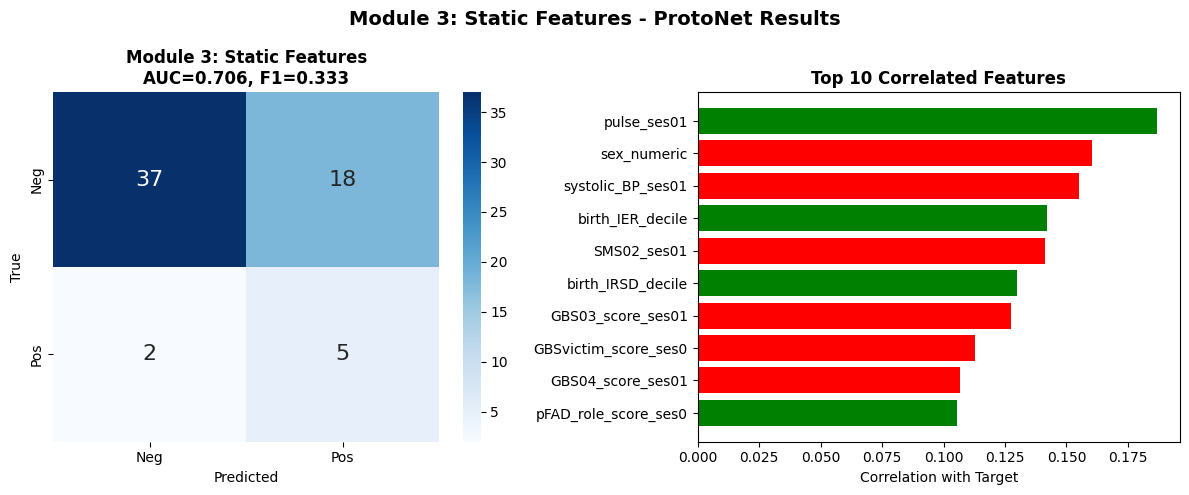

Saved: results_final/module3_results.json

MODULE 3 COMPLETE


In [ ]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
ax = axes[0]
cm = confusion_matrix(y_test, results['ProtoNet']['preds'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'],
            annot_kws={'size': 16})
ax.set_title(f'Module 3: Static Features\nAUC={results["ProtoNet"]["auc"]:.3f}, F1={results["ProtoNet"]["f1"]:.3f}',
              fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')

# Feature Importance (top 10 correlated)
ax = axes[1]
top_features = correlations[:10]
names = [c[1][:20] for c in top_features]
corrs = [c[2] for c in top_features]
colors = ['green' if c[3] > 0 else 'red' for c in top_features]
ax.barh(names, corrs, color=colors)
ax.set_xlabel('Correlation with Target')
ax.set_title('Top 10 Correlated Features', fontweight='bold')
ax.invert_yaxis()

plt.suptitle('Module 3: Static Features - ProtoNet Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results_final/module3_results.png', dpi=300, bbox_inches='tight')
print("Saved: results_final/module3_results.png")
plt.show()

# Save final results
final_results = {
    'version': 'Module 3: Static Features - ProtoNet',
    'techniques': ['Advanced ProtoNet', 'Focal+Center+Contrastive Loss', '3x Augmentation', 'RobustScaler', 'Feature Interactions'],
    'results': {
        'auc': float(results['ProtoNet']['auc']),
        'f1': float(results['ProtoNet']['f1']),
        'recall': float(results['ProtoNet']['rec']),
        'precision': float(results['ProtoNet']['prec']),
        'inverted': bool(proto_inverted)
    },
    'features': {
        'original': len(feature_names),
        'with_interactions': top_k,
        'top_5_correlated': [c[1] for c in correlations[:5]]
    }
}

with open('results_final/module3_results.json', 'w') as f:
    json.dump(final_results, f, indent=2)
print("Saved: results_final/module3_results.json")

print("\n" + "="*80)
print("MODULE 3 COMPLETE")
print("="*80)

## Architecture Diagram

Saved: results_final/module3_architecture.png


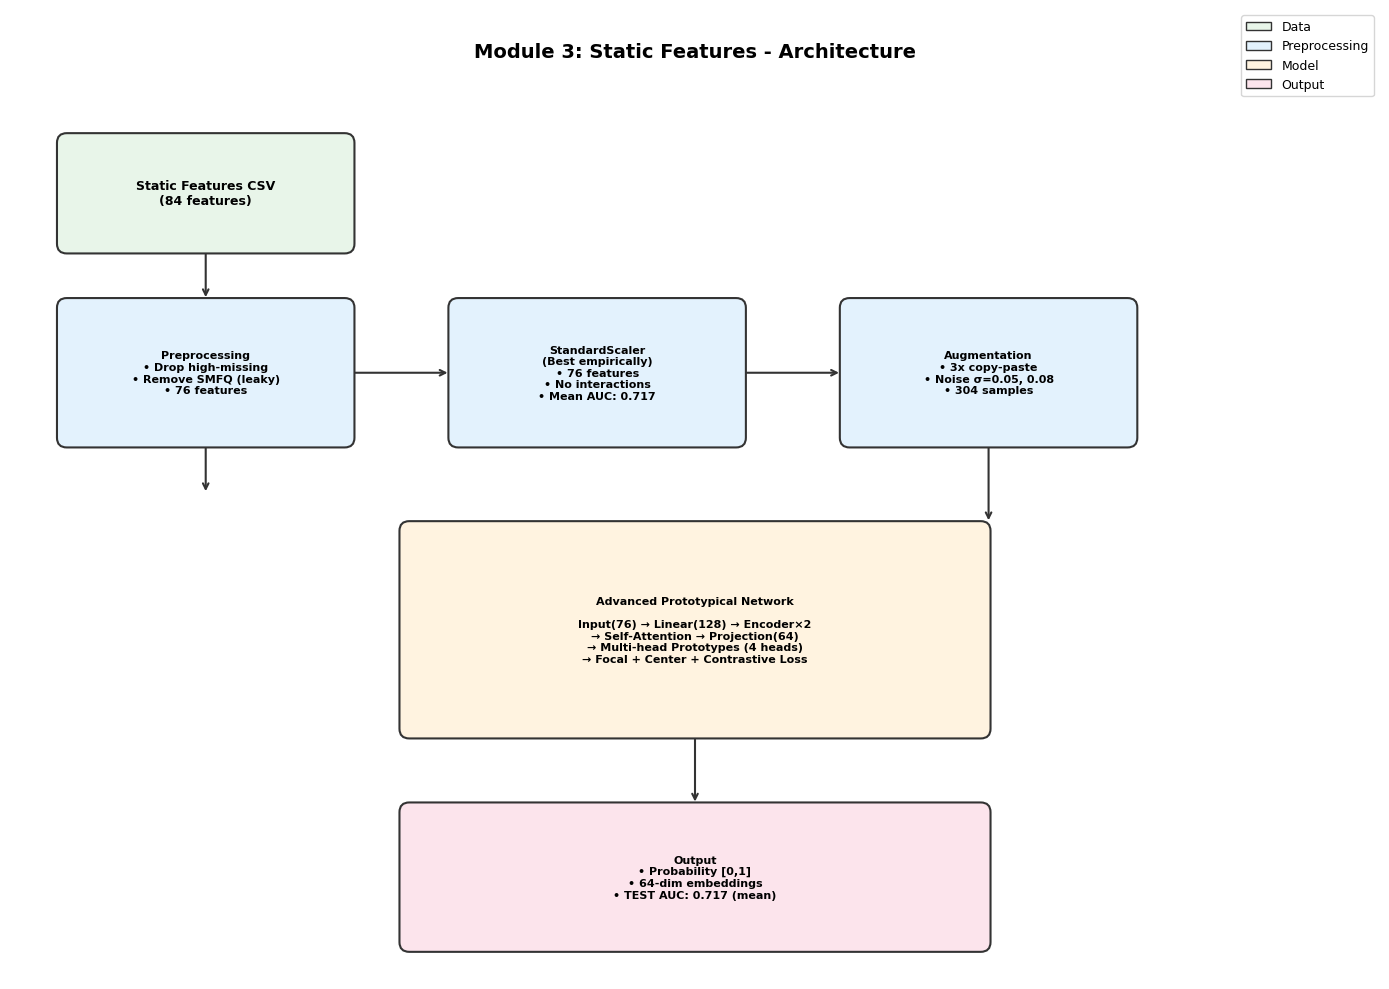

In [ ]:
# Module 3 Architecture Diagram
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis('off')

# Colors
c_data = '#E8F5E9'
c_preprocess = '#E3F2FD'
c_model = '#FFF3E0'
c_output = '#FCE4EC'
c_border = '#333333'

def box(x, y, w, h, text, color, fontsize=9):
    rect = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.1",
                          facecolor=color, edgecolor=c_border, linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=fontsize, fontweight='bold')

def arrow(x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=c_border, lw=1.5))

# Title
ax.text(7, 9.5, 'Module 3: Static Features - Architecture', fontsize=14, ha='center', fontweight='bold')

# 1. Input Data
box(0.5, 7.5, 3, 1.2, 'Static Features CSV\n(84 features)', c_data)

# 2. Preprocessing Pipeline
box(0.5, 5.5, 3, 1.5, 'Preprocessing\n• Drop high-missing\n• Remove SMFQ (leaky)\n• 76 features', c_preprocess, 8)

# 3. Feature Scaling (Simplified)
box(4.5, 5.5, 3, 1.5, 'StandardScaler\n(Best empirically)\n• 76 features\n• No interactions\n• Mean AUC: 0.717', c_preprocess, 8)

# 4. Augmentation
box(8.5, 5.5, 3, 1.5, 'Augmentation\n• 3x copy-paste\n• Noise σ=0.05, 0.08\n• 304 samples', c_preprocess, 8)

# 5. ProtoNet
box(4, 2.5, 6, 2.2, 'Advanced Prototypical Network\n\nInput(76) → Linear(128) → Encoder×2\n→ Self-Attention → Projection(64)\n→ Multi-head Prototypes (4 heads)\n→ Focal + Center + Contrastive Loss', c_model, 8)

# 6. Output
box(4, 0.3, 6, 1.5, 'Output\n• Probability [0,1]\n• 64-dim embeddings\n• TEST AUC: 0.717 (mean)', c_output, 8)

# Arrows
arrow(2, 7.5, 2, 7.0)
arrow(2, 5.5, 2, 5.0)
ax.annotate('', xy=(4.5, 6.25), xytext=(3.5, 6.25),
            arrowprops=dict(arrowstyle='->', color=c_border, lw=1.5))
ax.annotate('', xy=(8.5, 6.25), xytext=(7.5, 6.25),
            arrowprops=dict(arrowstyle='->', color=c_border, lw=1.5))
arrow(10, 5.5, 10, 4.7)
arrow(7, 2.5, 7, 1.8)

# Legend
legend_elements = [
    mpatches.Patch(facecolor=c_data, edgecolor=c_border, label='Data'),
    mpatches.Patch(facecolor=c_preprocess, edgecolor=c_border, label='Preprocessing'),
    mpatches.Patch(facecolor=c_model, edgecolor=c_border, label='Model'),
    mpatches.Patch(facecolor=c_output, edgecolor=c_border, label='Output'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('results_final/module3_architecture.png', dpi=300, bbox_inches='tight', facecolor='white')
print("Saved: results_final/module3_architecture.png")
plt.show()

Saved: results_final/module3_protonet_detail.png


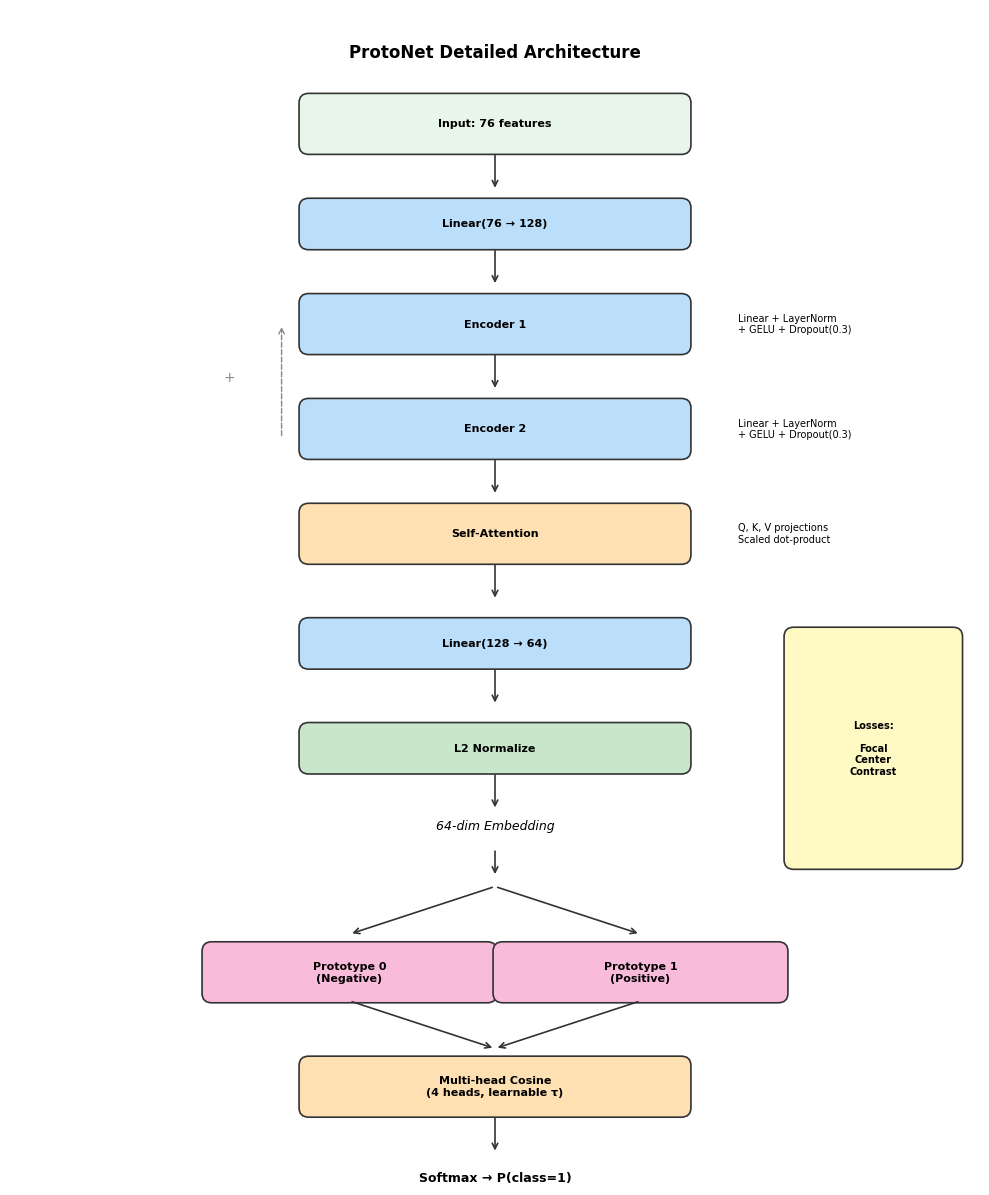

In [ ]:
# Detailed ProtoNet Architecture
fig, ax = plt.subplots(figsize=(10, 12))
ax.set_xlim(0, 10)
ax.set_ylim(0, 12)
ax.axis('off')

# Colors
c_input = '#E8F5E9'
c_linear = '#BBDEFB'
c_norm = '#C8E6C9'
c_attn = '#FFE0B2'
c_proto = '#F8BBD9'
c_output = '#E1BEE7'

def box(x, y, w, h, text, color, fs=8):
    rect = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.1",
                          facecolor=color, edgecolor='#333', linewidth=1.2)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=fs, fontweight='bold')

def arrow(x1, y1, x2, y2, label=''):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#333', lw=1.2))
    if label:
        ax.text((x1+x2)/2 + 0.3, (y1+y2)/2, label, fontsize=7, color='#666')

# Title
ax.text(5, 11.5, 'ProtoNet Detailed Architecture', fontsize=12, ha='center', fontweight='bold')

# Input
box(3, 10.5, 4, 0.6, 'Input: 76 features', c_input)
arrow(5, 10.5, 5, 10.1)

# Input projection
box(3, 9.5, 4, 0.5, 'Linear(76 → 128)', c_linear)
arrow(5, 9.5, 5, 9.1)

# Encoder 1
box(3, 8.4, 4, 0.6, 'Encoder 1', c_linear)
ax.text(7.5, 8.7, 'Linear + LayerNorm\n+ GELU + Dropout(0.3)', fontsize=7, va='center')
arrow(5, 8.4, 5, 8.0)

# Residual connection 1
ax.annotate('', xy=(2.8, 8.7), xytext=(2.8, 7.5),
            arrowprops=dict(arrowstyle='->', color='#888', lw=1, ls='--'))
ax.text(2.2, 8.1, '+', fontsize=10, color='#888')

# Encoder 2
box(3, 7.3, 4, 0.6, 'Encoder 2', c_linear)
ax.text(7.5, 7.6, 'Linear + LayerNorm\n+ GELU + Dropout(0.3)', fontsize=7, va='center')
arrow(5, 7.3, 5, 6.9)

# Self-Attention
box(3, 6.2, 4, 0.6, 'Self-Attention', c_attn)
ax.text(7.5, 6.5, 'Q, K, V projections\nScaled dot-product', fontsize=7, va='center')
arrow(5, 6.2, 5, 5.8)

# Projection
box(3, 5.1, 4, 0.5, 'Linear(128 → 64)', c_linear)
arrow(5, 5.1, 5, 4.7)

# L2 Normalize
box(3, 4.0, 4, 0.5, 'L2 Normalize', c_norm)
arrow(5, 4.0, 5, 3.6)

# Embeddings
ax.text(5, 3.4, '64-dim Embedding', fontsize=9, ha='center', style='italic')
arrow(5, 3.2, 5, 2.9)

# Split to prototypes
arrow(5, 2.8, 3.5, 2.3)
arrow(5, 2.8, 6.5, 2.3)

# Prototypes
box(2, 1.6, 3, 0.6, 'Prototype 0\n(Negative)', c_proto)
box(5, 1.6, 3, 0.6, 'Prototype 1\n(Positive)', c_proto)

# Merge
arrow(3.5, 1.6, 5, 1.1)
arrow(6.5, 1.6, 5, 1.1)

# Multi-head similarity
box(3, 0.4, 4, 0.6, 'Multi-head Cosine\n(4 heads, learnable τ)', c_attn)
arrow(5, 0.4, 5, 0.0)

# Output
ax.text(5, -0.3, 'Softmax → P(class=1)', fontsize=9, ha='center', fontweight='bold')

# Loss functions box
box(8, 3, 1.8, 2.5, 'Losses:\n\nFocal\nCenter\nContrast', '#FFF9C4', 7)

plt.tight_layout()
plt.savefig('results_final/module3_protonet_detail.png', dpi=300, bbox_inches='tight', facecolor='white')
print("Saved: results_final/module3_protonet_detail.png")
plt.show()